<a href="https://colab.research.google.com/github/saim9211/DeepLearning/blob/main/extras/exercises/03_pytorch_computer_vision_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03. PyTorch Computer Vision Exercises

The following is a collection of exercises based on computer vision fundamentals in PyTorch.

They're a bunch of fun.

You're going to get to write plenty of code!

## Resources

1. These exercises are based on [notebook 03 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/03_pytorch_computer_vision/).
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/_PibmqpEyhA).
  * **Note:** Going through these exercises took me just over 3 hours of solid coding, so you should expect around the same.
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [44]:
# Check for GPU
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
# Import torch
import torch

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# TODO: Setup device agnostic code
device= "cuda" if torch.cuda_is_available() else "cpu"


## 1. What are 3 areas in industry where computer vision is currently being used?

 object detection
 object recognition
 image segmentation

## 2. Search "what is overfitting in machine learning" and write down a sentence about what you find.

Overfitting in machine learning is like model learn  training data so well and perfrom good on it either then testing data

## 3. Search "ways to prevent overfitting in machine learning", write down 3 of the things you find and a sentence about each.
> **Note:** there are lots of these, so don't worry too much about all of them, just pick 3 and start with those.

feature selection,daat segmentation,regularization,dropout

## 4. Spend 20-minutes reading and clicking through the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/).

* Upload your own example image using the "upload" button on the website and see what happens in each layer of a CNN as your image passes through it.

## 5. Load the [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST) train and test datasets.

In [46]:
import torch
from torch import nn


import torchvision
from torchvision import datasets
from torchvision.transforms import  ToTensor
from torchvision.datasets import MNIST

train_data=datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)
test_data=datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

## 6. Visualize at least 5 different samples of the MNIST training dataset.

In [47]:
img,label=train_data[5]
img,label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

## 7. Turn the MNIST train and test datasets into dataloaders using `torch.utils.data.DataLoader`, set the `batch_size=32`.

In [48]:
from  torch.utils.data import DataLoader
train_dataloader=DataLoader(train_data,
                            batch_size=32 #how many samples per batch
                            ,shuffle=True) # shuffle data every epoch?

test_dataloader=DataLoader(test_data,batch_size=32,shuffle=True)

## 8. Recreate `model_2` used in notebook 03 (the same model from the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/), also known as TinyVGG) capable of fitting on the MNIST dataset.

In [49]:
from torch import nn
class MNIST(nn.Module):
  def __init__(self,input_shape:int,hidden_units:int,output_shape:int):
    super().__init__()
    self.layer1_stack=nn.Sequential(
        nn.Conv2d(in_channels=input_shape,out_channels=hidden_units,kernel_size=3,stride=1,padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units,kernel_size=3,stride=1,padding=1),
        nn.ReLU(),
      )
    self.layer2_stack=nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units,kernel_size=3,stride=1,padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units,kernel_size=3,stride=1,padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=2)
      )

    self.classifier=nn.Sequential(
        nn.Flatten(),
        # Corrected in_features for the Linear layer: 14x14 after one MaxPool2d on 28x28 input
        nn.Linear(in_features=hidden_units*14*14,out_features=output_shape)
    )
  def forward(self,x):
    # The forward pass should flow through layer1_stack -> layer2_stack -> classifier
    return self.classifier(self.layer2_stack(self.layer1_stack(x)))
model_0=MNIST(input_shape=1,hidden_units=10,output_shape=10)
model_0


MNIST(
  (layer1_stack): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
  )
  (layer2_stack): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1960, out_features=10, bias=True)
  )
)

## 9. Train the model you built in exercise 8. for 5 epochs on CPU and GPU and see how long it takes on each.

In [70]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device):
 train_loss,train_acc=0,0
 model.to(device)
 model.train()
 for batch,(X,y) in enumerate(dataloader):
   X,y=X.to(device),y.to(device)
   y_pred=model(X)


   # cal
   loss=loss_fn(y_pred,y)
   train_loss+=loss
   train_acc+=(y_pred.argmax(dim=1)==y).type(torch.float).mean()

   # optimizer to zero
   optimizer.zero_grad()
   loss.backward()
   optimizer.step()
 train_loss/=len(dataloader)
 train_acc/=len(dataloader)
 return train_loss,train_acc

def test_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               device: torch.device):
  test_loss,test_acc=0,0
  model.to(device)
  model.eval()

  with torch.inference_mode():
    for batch,(X,y) in enumerate(dataloader):
      X,y=X.to(device),y.to(device)
      test_pred=model(X)
      test_loss+=loss_fn(test_pred,y).item() # Use .item() to get scalar for accumulation
      test_acc+=(test_pred.argmax(dim=1)==y).type(torch.float).mean().item() # Use .item() to get scalar for accumulation
  test_loss/=len(dataloader)
  test_acc/=len(dataloader)
  return test_loss,test_acc

## 10. Make predictions using your trained model and visualize at least 5 of them comparing the prediciton to the target label.

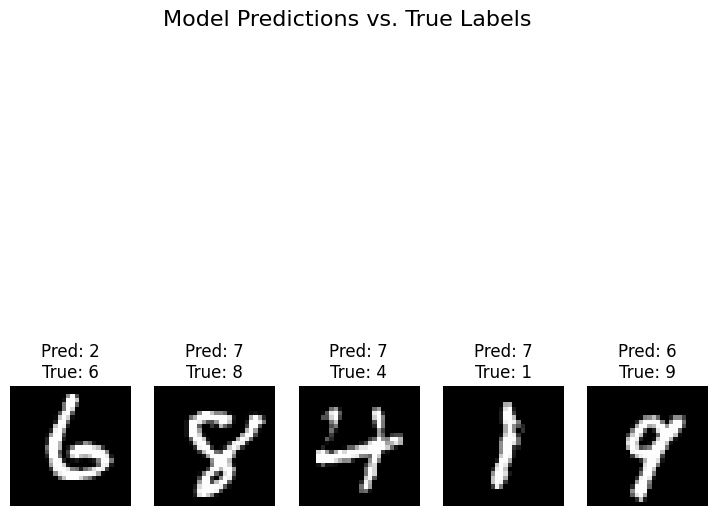

In [51]:
import matplotlib.pyplot as plt
import torch

# Setup device agnostic code (re-defining to ensure it's in scope)
device = "cuda" if torch.cuda.is_available() else "cpu"

# Put model in eval mode and move to device
model_0.to(device);
model_0.eval()

num_samples_to_visualize = 5

# Get a batch of test data
for X_test, y_test in test_dataloader:
    X_test, y_test = X_test.to(device), y_test.to(device)

    # Make predictions
    with torch.inference_mode():
        test_logits = model_0(X_test)
        test_preds = torch.softmax(test_logits, dim=1).argmax(dim=1)

    # Plot predictions
    plt.figure(figsize=(9, 9))
    for i in range(num_samples_to_visualize):
        plt.subplot(1, num_samples_to_visualize, i + 1)
        plt.imshow(X_test[i].squeeze().cpu().numpy(), cmap='gray')
        plt.title(f"Pred: {test_preds[i].item()}\nTrue: {y_test[i].item()}")
        plt.axis(False)
    plt.suptitle("Model Predictions vs. True Labels", fontsize=16)
    plt.show()
    break # Only visualize the first batch

## 11. Plot a confusion matrix comparing your model's predictions to the truth labels.

In [52]:
# See if torchmetrics exists, if not, install it
try:
    import torchmetrics, mlxtend
    print(f"mlxtend version: {mlxtend.__version__}")
    assert int(mlxtend.__version__.split(".")[1]) >= 19, "mlxtend verison should be 0.19.0 or higher"
except:
    !pip install -q torchmetrics -U mlxtend # <- Note: If you're using Google Colab, this may require restarting the runtime
    import torchmetrics, mlxtend
    print(f"mlxtend version: {mlxtend.__version__}")
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
confusion_matrix=ConfusionMatrix(num_classes=10,task='multiclass')
comf=confusion_matrix(test_preds,y_test)
comf

ImportError: cannot import name '_center' from 'numpy._core.umath' (/usr/local/lib/python3.12/dist-packages/numpy/_core/umath.py)

## 12. Create a random tensor of shape `[1, 3, 64, 64]` and pass it through a `nn.Conv2d()` layer with various hyperparameter settings (these can be any settings you choose), what do you notice if the `kernel_size` parameter goes up and down?

In [54]:
import torch
from torch import nn
tensor=torch.randn(1,3,64,64)
test_img=tensor[0]
test_img


torch.manual_seed(42)

con_layer=nn.Conv2d(in_channels=3,out_channels=10,kernel_size=3,stride=1,padding=1)
con_layer(test_img.unsqueeze(dim=0))


tensor([[[[ 1.1863e-01,  5.1259e-01,  3.4355e-01,  ...,  3.3271e-01,
           -1.6988e-01,  3.4831e-01],
          [-6.1478e-02,  5.7896e-01, -5.4762e-02,  ...,  1.4445e-01,
            5.9131e-01,  1.6971e-01],
          [-1.0087e-01,  7.9018e-03,  5.4954e-01,  ..., -3.0959e-01,
           -8.3114e-01,  5.7526e-01],
          ...,
          [ 5.0616e-01, -4.5770e-01, -2.4881e-01,  ...,  5.3874e-01,
           -3.3944e-01, -1.8140e-01],
          [ 1.0921e-01,  2.9385e-02, -3.1369e-01,  ..., -2.7256e-01,
            3.5523e-03,  1.3414e-01],
          [ 5.1297e-01,  3.4851e-01, -6.6992e-01,  ..., -7.8555e-02,
           -1.4704e-01,  5.8255e-01]],

         [[-5.8622e-01,  7.5636e-01, -2.9002e-01,  ...,  1.5096e-01,
            5.2072e-02, -3.8870e-01],
          [-4.8314e-01,  5.1055e-02, -5.7017e-01,  ..., -8.6592e-01,
           -8.0407e-01, -5.7880e-01],
          [-6.2705e-01,  3.7162e-01, -1.4982e-01,  ..., -1.9254e-01,
           -3.3255e-01, -3.8438e-01],
          ...,
     

## 13. Use a model similar to the trained `model_2` from notebook 03 to make predictions on the test [`torchvision.datasets.FashionMNIST`](https://pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html) dataset.
* Then plot some predictions where the model was wrong alongside what the label of the image should've been.
* After visualing these predictions do you think it's more of a modelling error or a data error?
* As in, could the model do better or are the labels of the data too close to each other (e.g. a "Shirt" label is too close to "T-shirt/top")?

In [55]:
from torchvision import datasets
from torchvision.transforms import ToTensor
test_data=datasets.FashionMNIST(
    train=True,transform=ToTensor(),
    root="data",
    download=True
)
train_data=datasets.FashionMNIST(
    train=False,transform=ToTensor(),
    root="data",
    download=True
)

In [67]:
class FashionMNIST(nn.Module):
  def __init__(self,input_shape:int,hidden_units:int,output_shape:int ):
    super().__init__()
    self.layer1_stack=nn.Sequential(
        nn.Conv2d(in_channels=input_shape,out_channels=hidden_units,kernel_size=3,stride=1,padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units,kernel_size=3,stride=1,padding=1),
        nn.ReLU(),

    )
    self.layer2_stack=nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units,kernel_size=3,stride=1,padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=2),
        nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units,kernel_size=3,stride=1,padding=1),
    )
    self.classifier=nn.Sequential(
        nn.Flatten(),
        # Corrected in_features: (hidden_units * 14 * 14) after MaxPool2d on a 28x28 input
        nn.Linear(in_features=hidden_units*14*14,out_features=output_shape)

    )
  def forward(self,x): # Corrected from 'forwad' to 'forward'
    return self.classifier(self.layer2_stack(self.layer1_stack(x)))

model_1=FashionMNIST(input_shape=1,hidden_units=10,output_shape=10)
model_1

FashionMNIST(
  (layer1_stack): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
  )
  (layer2_stack): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1960, out_features=10, bias=True)
  )
)

In [68]:
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model_1.parameters(),lr=0.001)

In [71]:
torch.manual_seed(42)
epochs=3
for epoch in range(epochs):
  train_loss,train_acc=train_step(model=model_1,dataloader=train_dataloader,loss_fn=loss_fn,optimizer=optimizer,device=device)
  test_loss,test_acc=test_step(model=model_1,dataloader=test_dataloader,loss_fn=loss_fn,device=device)
  print(f"Epoch: {epoch+1} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

KeyboardInterrupt: 